### K Means Clustering

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [3]:
X

array([[ 9.57093253,  6.69852542],
       [-2.87644896, -0.85390681],
       [ 9.33123299,  6.93489912],
       ...,
       [ 9.02077123, -1.55942951],
       [ 9.03248249, -1.41997972],
       [ 8.58760371,  5.09312036]])

In [4]:
y

array([1, 0, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 1, 1, 2,
       0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 0, 0, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1,
       1, 0, 1, 2, 1, 2, 1, 0, 0, 2, 1, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 2,
       0, 2, 2, 0, 0, 1, 2, 1, 1, 2, 2, 1, 2, 1, 0, 2, 0, 2, 2, 2, 0, 2,
       1, 1, 2, 2, 0, 0, 0, 0, 1, 2, 0, 0, 1, 1, 2, 2, 0, 1, 2, 2, 0, 1,
       0, 2, 0, 0, 0, 0, 2, 1, 2, 0, 0, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 1, 1, 2, 2, 0, 0, 2, 1, 2, 0, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 1, 0, 0, 0, 1, 2, 1,
       0, 2, 0, 0, 2, 2, 0, 2, 1, 2, 1, 2, 0, 1, 0, 1, 1, 2, 1, 2, 1, 2,
       2, 1, 0, 1, 1, 2, 2, 2, 1, 0, 2, 1, 2, 2, 2, 2, 0, 2, 2, 1, 1, 0,
       1, 1, 0, 0, 0, 2, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 2, 1, 1, 0, 0,
       1, 0, 0, 2, 2, 0, 2, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 0, 1, 2,
       0, 0, 2, 2, 0, 0, 0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 0, 0, 2, 1, 0, 1,
       2, 2, 0, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 1, 1,

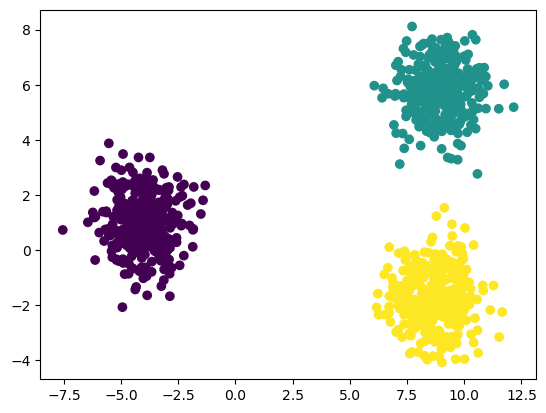

In [6]:
plt.scatter(X[:,0],X[:,1], c = y)

In [7]:
# standardization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [10]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.cluster import KMeans

In [13]:
# elbow method to select k value
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

d:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^

In [14]:
wcss

[1339.9999999999998,
 629.6900754264742,
 78.60991496840992,
 66.95691615228324,
 60.58311428827933,
 39.54015399487249,
 35.16641531700237,
 31.1015229494783,
 27.88818248341169,
 25.659446682429177]

Text(0, 0.5, 'WCSS')

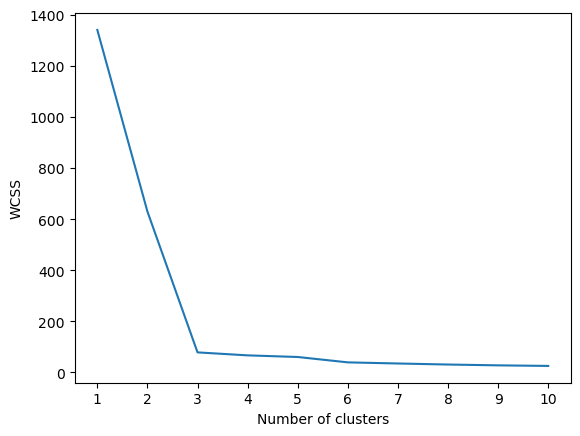

In [15]:
# plot elbow curve 
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")

In [16]:
kmeans = KMeans(n_clusters=3, init="k-means++")

In [17]:
kmeans.fit_predict(X_train_scaled)

d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([2, 2, 1, 0, 0, 0, 0, 2, 1, 0, 1, 2, 2, 0, 1, 1, 2, 2, 1, 0, 1, 2,
       2, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 0, 1, 1, 1, 1, 0, 2, 0, 0, 2, 0,
       1, 2, 0, 0, 2, 0, 0, 1, 0, 2, 0, 2, 1, 2, 1, 2, 1, 1, 0, 2, 0, 1,
       0, 2, 2, 1, 1, 2, 0, 1, 1, 0, 1, 0, 2, 2, 2, 1, 0, 2, 0, 2, 1, 0,
       2, 2, 1, 2, 0, 1, 0, 2, 1, 1, 1, 2, 0, 1, 0, 1, 2, 1, 2, 2, 0, 0,
       2, 0, 1, 2, 2, 2, 2, 2, 1, 2, 0, 0, 1, 1, 1, 1, 0, 1, 2, 2, 0, 2,
       0, 1, 2, 2, 2, 1, 1, 2, 0, 2, 1, 0, 0, 0, 1, 1, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 2, 2, 1, 1, 2, 1, 0, 2, 2, 2, 0, 2, 1, 2, 1, 0, 0, 2, 1,
       2, 1, 0, 1, 1, 0, 2, 2, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1, 2, 1, 2, 1,
       1, 2, 0, 1, 1, 2, 0, 1, 0, 1, 0, 2, 2, 1, 2, 1, 0, 1, 2, 1, 0, 0,
       1, 2, 2, 0, 2, 2, 0, 2, 0, 2, 1, 0, 1, 2, 1, 2, 0, 0, 0, 2, 0, 1,
       0, 0, 1, 2, 0, 2, 1, 0, 2, 0, 2, 1, 1, 1, 2, 2, 0, 0, 1, 0, 2, 0,
       1, 0, 1, 2, 1, 0, 1, 1, 2, 1, 1, 1, 2, 2, 0, 2, 1, 0, 2, 2, 0, 0,
       1, 1, 1, 2, 0, 1, 1, 2, 2, 0, 0, 0, 1, 0, 1,

In [18]:
y_pred = kmeans.predict(X_test_scaled)

In [19]:
y_pred

array([0, 2, 1, 2, 1, 1, 1, 1, 0, 2, 2, 1, 1, 1, 0, 1, 2, 0, 0, 2, 2, 1,
       0, 0, 1, 2, 0, 0, 2, 2, 2, 2, 2, 0, 1, 1, 2, 0, 0, 1, 2, 0, 2, 1,
       0, 1, 2, 2, 0, 2, 0, 0, 2, 2, 1, 1, 1, 2, 0, 0, 0, 0, 1, 0, 0, 0,
       2, 1, 2, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 2, 0, 1, 0, 0, 1, 0,
       2, 2, 1, 1, 0, 0, 1, 2, 2, 0, 1, 2, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1,
       1, 1, 1, 2, 2, 1, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 2, 2, 2, 0, 2,
       2, 1, 1, 0, 2, 1, 0, 1, 0, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 2, 2, 2, 2, 1, 2, 1, 0, 2, 0, 1, 0,
       1, 0, 2, 0, 2, 1, 0, 0, 2, 2, 1, 0, 0, 1, 2, 2, 1, 0, 1, 2, 0, 1,
       0, 1, 1, 0, 1, 0, 2, 2, 0, 2, 0, 2, 1, 1, 1, 1, 0, 0, 1, 2, 2, 1,
       2, 2, 2, 1, 1, 0, 0, 1, 0, 2, 2, 2, 2, 1, 2, 1, 0, 1, 0, 0, 1, 1,
       2, 1, 2, 0, 0, 0, 1, 1, 2, 1, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 1,
       2, 0, 2, 0, 1, 1, 2, 1, 1, 2, 2, 2, 0, 0, 1, 1, 2, 2, 0, 2, 1, 1,
       2, 0, 0, 0, 1, 1, 0, 2, 0, 2, 2, 0, 2, 0, 2,

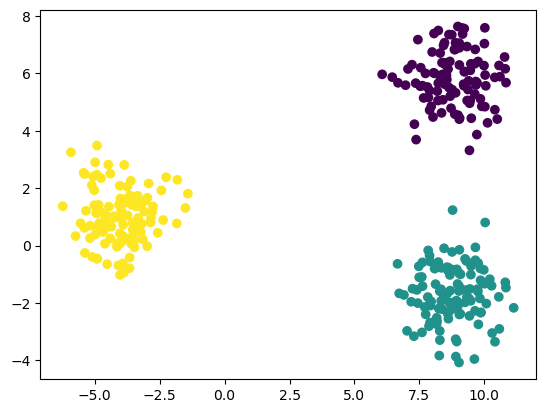

In [20]:
plt.scatter(X_test[:,0],X_test[:,1],c = y_pred)

In [ ]:
# validating the k value 
# technique 1 - kneelocator 
# silhoutee scoring 

In [21]:
# kneelocator 
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [22]:
from kneed import KneeLocator

In [23]:
kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")

In [24]:
kl.elbow

3

In [25]:
# technique 2 - silhoutee scoring 
from sklearn.metrics import silhouette_score

In [27]:
silhouettee_coefficients = []
for k in range (2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouettee_coefficients.append(score)

d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

In [28]:
silhouettee_coefficients

[0.5652474583138591,
 0.8092452711297172,
 0.6713390758518316,
 0.5449209925111624,
 0.41976273286261284,
 0.40336795732232766,
 0.3836814430945478,
 0.3680542795796234,
 0.3556845076415239]

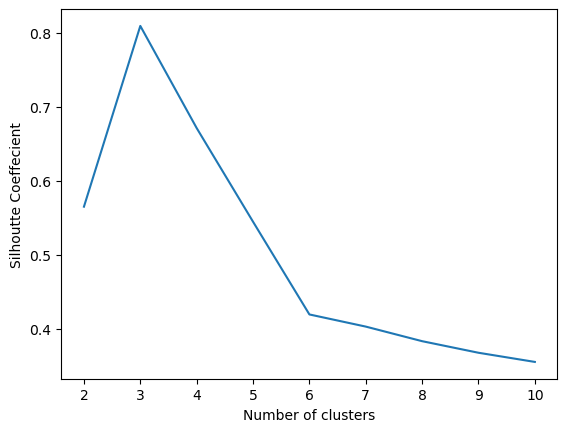

In [29]:
# plotting silhoutee score 
plt.plot(range(2, 11), silhouettee_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()